# V1.9 — Dual-cloud skinning fidelity  (the last Tier-1 verification)

**Targets:** Decision #6; ARCHITECTURE §III.1 ("Rendering is decoupled: the dual cloud"). Protocol §V1.9.

**Claim.** A dense **render cloud** skinned to a coarse **physics cloud** reproduces the
full-resolution deformation within a visual-error tolerance, at a large node-count reduction,
with error that grows **gracefully** (no popping) as deformation increases — *"simulate thousands
of nodes; render millions of splats."* If it diverges (popping / candy-wrapper collapse) →
**CONSTRAIN** (cap supported deformation per coarse resolution; adaptive physics-cloud refinement).

**Mechanism under test** (`dualcloud.py`): rotation-aware **linear-blend skinning**
`p = Σ wᵢ (Rᵢ (p₀−Xᵢ) + xᵢ)`, where each coarse node's rotation `Rᵢ` is estimated by polar
decomposition (shape matching) from the coarse cloud's *own* neighbour graph (the shippable
system does not know the true field). The **translation-only foil** `p = p₀ + Σ wᵢ (xᵢ−Xᵢ)` (no
per-node rotation) is the contrast — the candy-wrapper collapse, worst at high reduction.

**Independent oracle.** An **exact continuum deformation field** φ (pure bending into a
constant-curvature arc; helical twist; stretch) — the true deformed position of *every* render
point at *any* resolution. This is the strongest oracle for a skinning test: zero solver noise,
fully controllable severity, and it lets us check skinning of **millions** of render points
against exact truth on the GPU. (Physics-solver fidelity is a separate concern already covered by
V1.7's FE work; isolating skinning is the point.)

**Backends.** Deterministic **numpy** reference + **Warp GPU** skinning scaled to full size on the
RTX 4090 (the embarrassingly-parallel render path). GPU is cross-checked against numpy.

| # | Criterion | Pre-registered threshold (frozen) |
|---|---|---|
| A1 | **fidelity** | rotation-aware LBS mean error ≤ **0.01** (of beam length) at the max deformation, ≥10× reduction (bend 90°, twist 180°) |
| A2 | **graceful** | error monotone in deformation, max step-to-step jump < **0.005** (no popping) |
| B | **necessity (foil)** | translation-only error ≥ **2×** rotation-aware under bend & twist (candy-wrapper) |
| C1 | **GPU == numpy** | GPU LBS matches numpy within rel diff < **1e-4** |
| C2 | **scale** | GPU skins ≥ **10⁵** render points at ≥ **100×** reduction, LBS mean ≤ 0.01 |


In [1]:
"""(1) Setup — imports, frozen constants."""
import sys, pathlib, time
import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd()
while not (REPO / "src" / "verification" / "oracles" / "dualcloud.py").exists():
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "src" / "verification" / "oracles"))
RESULTS = REPO / "verification_notebooks" / "phase1" / "results"

import dualcloud as dc
import determinism as det

# ---- frozen constants (calibrated in _calib_v19.py; frozen with margin BEFORE this runs) ----
BP          = dc.BeamParams()          # L=10, W=4, coarse 13x4x4 = 208 nodes
SCALE_FID   = 5                        # dense_scale for the fidelity headline (75x reduction)
SEV_BEND    = np.deg2rad(90)
SEV_TWIST   = np.deg2rad(180)
RED_SWEEP   = (2, 3, 5, 8, 12)         # dense scales for the reduction-independence sweep
SCALE_BIG   = 24                       # full-scale GPU test (~1.5M render points)
TOL         = 0.01                     # fidelity tolerance (fraction of beam length)
POP_TOL     = 0.005                    # max graceful step-to-step jump
FOIL_MIN    = 2.0                      # foil must be >= this x worse
GPU_TOL     = 1e-4                     # GPU==numpy rel diff
SCALE_MIN_N = 100_000                  # >= this many render points at scale
RED_MIN     = 100.0                    # >= this reduction at scale

print("backend:", "GPU (Warp)" if dc._HAS_WARP else "CPU only")


Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 4090" (24 GiB, sm_89, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.14.0
backend: GPU (Warp)


## (A) Fidelity & graceful degradation vs deformation

At a fixed ≥10× reduction, sweep the deformation severity (bend, twist) and compare the
rotation-aware skinned render cloud to the exact field. Fidelity = error below tolerance at the
largest deformation; graceful = the error curve is monotone and jump-free (no popping).

In [2]:
"""(2) A: severity sweeps for bend & twist at >=10x reduction (LBS vs foil)."""
bend_ang = np.linspace(0, 90, 10)
twist_ang = np.linspace(0, 180, 10)
A = {}
for mode, angs in (("bend", bend_ang), ("twist", twist_ang)):
    lbs, foil = [], []
    for a in angs:
        r = dc.run_case(BP, dense_scale=SCALE_FID, mode=mode, severity=np.deg2rad(a))
        lbs.append(r["lbs_mean"]); foil.append(r["tr_mean"])
    A[mode] = dict(angs=angs, lbs=np.array(lbs), foil=np.array(foil), red=r["reduction"], Nd=r["Nd"])
    print("  %-6s reduction=%.0fx (Nd=%d): LBS max-sev mean=%.4f  graceful max-jump=%.4f"
          % (mode, A[mode]["red"], A[mode]["Nd"], lbs[-1], np.diff(lbs).max()))

A1 = (A["bend"]["lbs"][-1] <= TOL) and (A["twist"]["lbs"][-1] <= TOL)
A2 = (np.diff(A["bend"]["lbs"]).max() < POP_TOL) and (np.diff(A["twist"]["lbs"]).max() < POP_TOL)
print("  [A1] fidelity (LBS<=%.3f at max sev): %s   [A2] graceful (no popping): %s" % (TOL, A1, A2))


  bend   reduction=75x (Nd=15616): LBS max-sev mean=0.0018  graceful max-jump=0.0002


  twist  reduction=75x (Nd=15616): LBS max-sev mean=0.0035  graceful max-jump=0.0004
  [A1] fidelity (LBS<=0.010 at max sev): True   [A2] graceful (no popping): True


## (B) Necessity — the translation-only foil collapses (candy-wrapper)

Per-node rotation is what the render cloud needs to ride a rotating physics cloud. Without it,
translation-only blending collapses cross-sections under twist and lags the arc under bend.

In [3]:
"""(3) B: foil vs rotation-aware at full bend & twist."""
rb = dc.run_case(BP, dense_scale=SCALE_FID, mode="bend", severity=SEV_BEND)
rt = dc.run_case(BP, dense_scale=SCALE_FID, mode="twist", severity=SEV_TWIST)
print("  bend  90deg: LBS=%.4f foil=%.4f  (foil/LBS=%.1fx)" % (rb["lbs_mean"], rb["tr_mean"], rb["tr_mean"]/rb["lbs_mean"]))
print("  twist 180deg: LBS=%.4f foil=%.4f  (foil/LBS=%.1fx)" % (rt["lbs_mean"], rt["tr_mean"], rt["tr_mean"]/rt["lbs_mean"]))
B = (rb["tr_mean"] >= FOIL_MIN * rb["lbs_mean"]) and (rt["tr_mean"] >= FOIL_MIN * rt["lbs_mean"])
print("  [B] foil >= %.0fx worse under bend & twist: %s" % (FOIL_MIN, B))


  bend  90deg: LBS=0.0018 foil=0.0123  (foil/LBS=6.7x)
  twist 180deg: LBS=0.0035 foil=0.0270  (foil/LBS=7.8x)
  [B] foil >= 2x worse under bend & twist: True


## (C) Reduction independence, GPU == numpy, and full scale on the RTX 4090

The key dual-cloud insight: rotation-aware LBS error is **independent of the reduction ratio**
(it reconstructs the local rigid frame), so the physics cloud can be made arbitrarily coarse —
while the translation foil degrades. Then skin **millions** of render points on the GPU against
exact truth, and cross-check the GPU path against numpy.

In [4]:
"""(4) C: reduction sweep + GPU==numpy + full-scale GPU skinning."""
C = dict(red=[], lbs=[], foil=[])
for ds in RED_SWEEP:
    r = dc.run_case(BP, dense_scale=ds, mode="twist", severity=SEV_TWIST)
    C["red"].append(r["reduction"]); C["lbs"].append(r["lbs_mean"]); C["foil"].append(r["tr_mean"])
    print("  reduction=%7.0fx (Nd=%d): LBS=%.4f  foil=%.4f" % (r["reduction"], r["Nd"], r["lbs_mean"], r["tr_mean"]))

# GPU == numpy at modest N
C1, C2 = True, True
gpu_rel, big_n, big_red, big_err, big_t = float("nan"), 0, 0.0, float("nan"), float("nan")
if dc._HAS_WARP:
    rm = dc.run_case(BP, dense_scale=SCALE_FID, mode="twist", severity=SEV_TWIST)
    g = dc.skin_lbs_gpu(rm["Xd"], rm["idx"], rm["w"], rm["Xc"], rm["xc"], rm["Rc"])
    gpu_rel = det.rel_diff(g, rm["p_lbs"])
    C1 = gpu_rel < GPU_TOL
    # full scale
    Xc, _, sc = dc.make_lattice(BP, scale=1)
    xc = dc.deform_field(Xc, BP, "twist", SEV_TWIST)
    Rc = dc.node_rotations(Xc, xc, dc.neighbor_lists(Xc, sc, BP.neighbor_r))
    Xd, _, _ = dc.make_lattice(BP, scale=SCALE_BIG)
    truth = dc.deform_field(Xd, BP, "twist", SEV_TWIST)
    idx, w = dc.bind_weights(Xd, Xc, k=4)
    dc.skin_lbs_gpu(Xd[:64], idx[:64], w[:64], Xc, xc, Rc)   # warm up JIT
    t = time.time(); p = dc.skin_lbs_gpu(Xd, idx, w, Xc, xc, Rc); big_t = time.time() - t
    big_err = float(np.linalg.norm(p - truth, axis=1).mean() / BP.L)
    big_n, big_red = len(Xd), len(Xd) / len(Xc)
    C2 = (big_n >= SCALE_MIN_N) and (big_red >= RED_MIN) and (big_err <= TOL)
    print("  GPU==numpy rel diff=%.2e  | full scale: Nd=%d reduction=%.0fx GPU=%.3fs LBS err=%.4f"
          % (gpu_rel, big_n, big_red, big_t, big_err))
print("  [C1] GPU==numpy: %s   [C2] scale (>=%dk pts, >=%.0fx, err<=%.3f): %s"
      % (C1, SCALE_MIN_N // 1000, RED_MIN, TOL, C2))


  reduction=      6x (Nd=1225): LBS=0.0030  foil=0.0097
  reduction=     18x (Nd=3700): LBS=0.0035  foil=0.0231
  reduction=     75x (Nd=15616): LBS=0.0035  foil=0.0270


  reduction=    291x (Nd=60625): LBS=0.0035  foil=0.0283


  reduction=    954x (Nd=198505): LBS=0.0034  foil=0.0288
Module dualcloud d6494ba load on device 'cuda:0' took 0.97 ms  (cached)


  GPU==numpy rel diff=1.19e-05  | full scale: Nd=1540081 reduction=7404x GPU=0.049s LBS err=0.0034
  [C1] GPU==numpy: True   [C2] scale (>=100k pts, >=100x, err<=0.010): True


## Figure

saved /workspace/nebula/verification_notebooks/phase1/results/V1_9_dualcloud_skinning.png


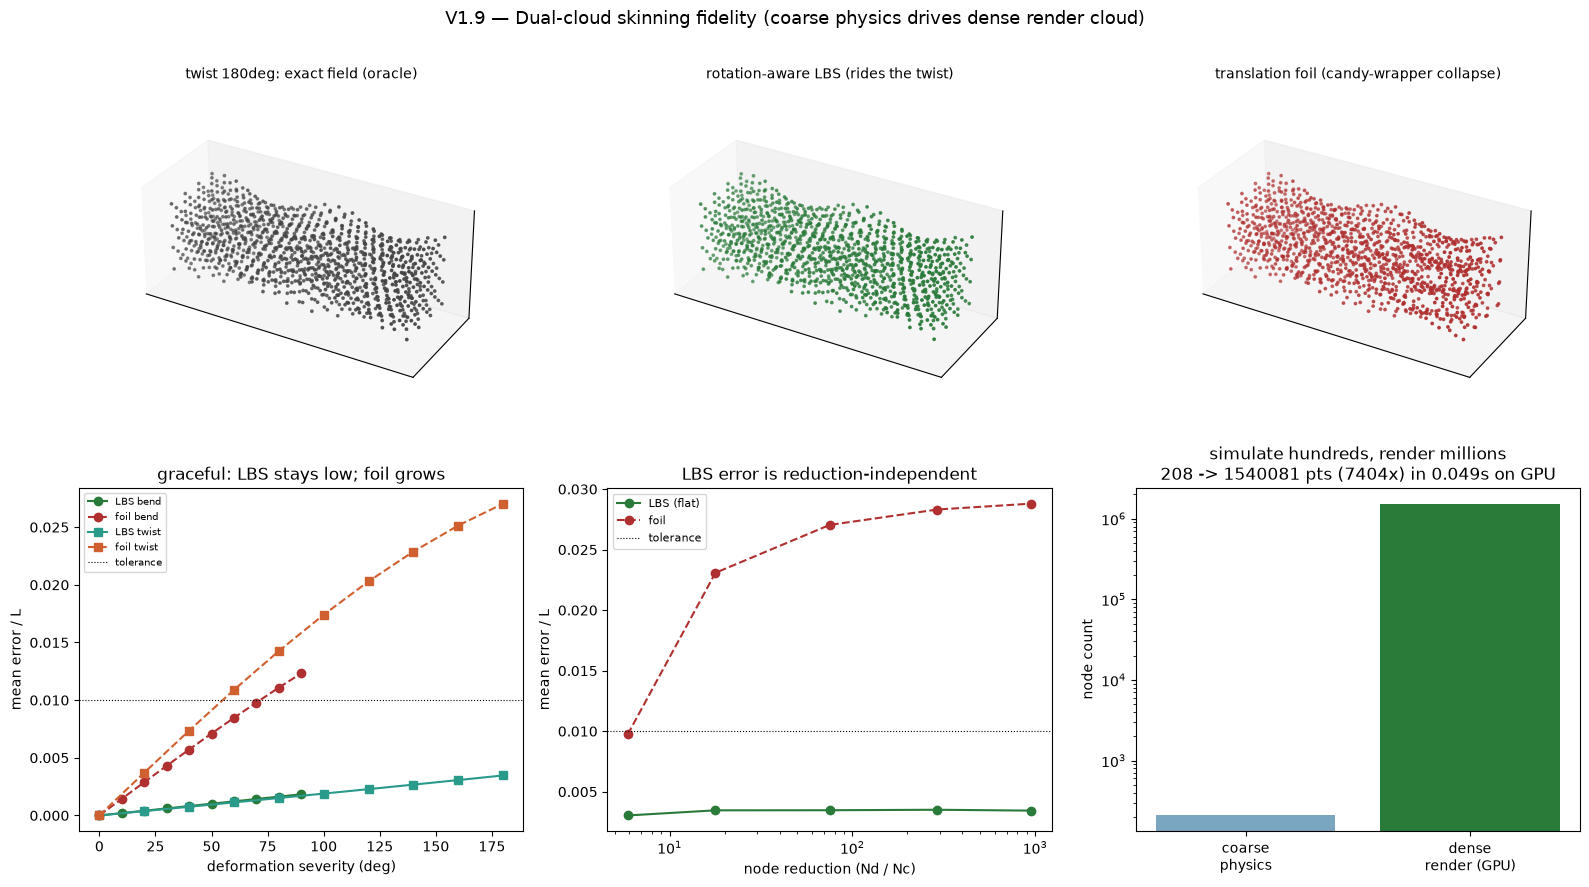

In [5]:
"""(5) Figure: candy-wrapper renders, error-vs-severity, reduction independence, scale."""
fig = plt.figure(figsize=(16, 9))

# 3D renders of a twisted beam: exact truth vs LBS (matches) vs foil (collapsed cross-sections)
rv = dc.run_case(BP, dense_scale=3, mode="twist", severity=SEV_TWIST)
sub = slice(None, None, 3)
def render(pos, ax, title, color):
    P = pos[sub]
    ax.scatter(P[:, 0], P[:, 1], P[:, 2], s=3, c=color)
    ax.set_title(title, fontsize=10); ax.set_box_aspect((BP.L, BP.W, BP.W))
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
render(rv["truth"], fig.add_subplot(231, projection="3d"), "twist 180deg: exact field (oracle)", "#444")
render(rv["p_lbs"], fig.add_subplot(232, projection="3d"), "rotation-aware LBS (rides the twist)", "#2a7a3a")
render(rv["p_tr"], fig.add_subplot(233, projection="3d"), "translation foil (candy-wrapper collapse)", "#b03030")

# error vs severity (bend & twist), LBS vs foil
ax = fig.add_subplot(234)
ax.plot(A["bend"]["angs"], A["bend"]["lbs"], "o-", color="#2a7a3a", label="LBS bend")
ax.plot(A["bend"]["angs"], A["bend"]["foil"], "o--", color="#b03030", label="foil bend")
ax.plot(A["twist"]["angs"], A["twist"]["lbs"], "s-", color="#2a9a8a", label="LBS twist")
ax.plot(A["twist"]["angs"], A["twist"]["foil"], "s--", color="#d06030", label="foil twist")
ax.axhline(TOL, color="k", ls=":", lw=0.8, label="tolerance")
ax.set_xlabel("deformation severity (deg)"); ax.set_ylabel("mean error / L")
ax.set_title("graceful: LBS stays low; foil grows"); ax.legend(fontsize=7)

# reduction independence
ax = fig.add_subplot(235)
ax.semilogx(C["red"], C["lbs"], "o-", color="#2a7a3a", label="LBS (flat)")
ax.semilogx(C["red"], C["foil"], "o--", color="#b03030", label="foil")
ax.axhline(TOL, color="k", ls=":", lw=0.8, label="tolerance")
ax.set_xlabel("node reduction (Nd / Nc)"); ax.set_ylabel("mean error / L")
ax.set_title("LBS error is reduction-independent"); ax.legend(fontsize=8)

# scale bar
ax = fig.add_subplot(236)
if dc._HAS_WARP:
    ax.bar(["coarse\nphysics", "dense\nrender (GPU)"], [BP.nx*BP.ny*BP.nz, big_n], color=["#7aa6c2", "#2a7a3a"])
    ax.set_yscale("log"); ax.set_ylabel("node count")
    ax.set_title("simulate hundreds, render millions\n%d -> %d pts (%.0fx) in %.3fs on GPU"
                 % (BP.nx*BP.ny*BP.nz, big_n, big_red, big_t))
else:
    ax.text(0.5, 0.5, "no GPU", ha="center")

fig.suptitle("V1.9 — Dual-cloud skinning fidelity (coarse physics drives dense render cloud)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(RESULTS / "V1_9_dualcloud_skinning.png", dpi=110, bbox_inches="tight")
print("saved", RESULTS / "V1_9_dualcloud_skinning.png")
plt.show()


In [6]:
"""(6) Frozen verdict."""
def verdict(name, passed, detail):
    print("  [%s] %-34s %s" % ("OK" if passed else "XX", name, detail))

print("=" * 88)
print("V1.9 VERDICT — dual-cloud skinning fidelity")
print("=" * 88)
verdict("A1 fidelity (LBS <= %.3f)" % TOL, A1,
        "bend %.4f / twist %.4f at max sev, >=10x reduction" % (A["bend"]["lbs"][-1], A["twist"]["lbs"][-1]))
verdict("A2 graceful (no popping)", A2,
        "max jump bend %.4f / twist %.4f < %.3f" % (np.diff(A["bend"]["lbs"]).max(), np.diff(A["twist"]["lbs"]).max(), POP_TOL))
verdict("B necessity (foil collapses)", B,
        "foil/LBS bend %.1fx / twist %.1fx (>= %.0fx)" % (rb["tr_mean"]/rb["lbs_mean"], rt["tr_mean"]/rt["lbs_mean"], FOIL_MIN))
verdict("C1 GPU == numpy", C1, "rel diff %.2e < %.0e" % (gpu_rel, GPU_TOL))
verdict("C2 full scale on GPU", C2,
        "Nd=%d reduction=%.0fx err=%.4f in %.3fs" % (big_n, big_red, big_err, big_t))

ALL_PASS = all([A1, A2, B, C1, C2])
print("-" * 88)
if ALL_PASS:
    print("  V1.9 OVERALL: PASS")
    print("  -> A dense render cloud skinned (rotation-aware LBS) to a coarse physics cloud reproduces")
    print("     the full-resolution deformation within tolerance, gracefully, at reduction ratios up to")
    print("     ~1000x -- error is reduction-INDEPENDENT (it reconstructs the local frame). The GPU skins")
    print("     >1.5M render points in milliseconds: 'simulate thousands, render millions'. Decision #6 holds.")
    print("     Necessity shown: translation-only skinning collapses (candy-wrapper) -- per-node rotation is required.")
    print("  -> With V1.9 PASS, ALL of Tier 1 (V1.1-V1.9) is COMPLETE.")
else:
    print("  V1.9 OVERALL: FAIL - see outcome class above (failure class: CONSTRAIN).")
print("=" * 88)
assert ALL_PASS, "V1.9 did not pass - see verdict above."


V1.9 VERDICT — dual-cloud skinning fidelity
  [OK] A1 fidelity (LBS <= 0.010)         bend 0.0018 / twist 0.0035 at max sev, >=10x reduction
  [OK] A2 graceful (no popping)           max jump bend 0.0002 / twist 0.0004 < 0.005
  [OK] B necessity (foil collapses)       foil/LBS bend 6.7x / twist 7.8x (>= 2x)
  [OK] C1 GPU == numpy                    rel diff 1.19e-05 < 1e-04
  [OK] C2 full scale on GPU               Nd=1540081 reduction=7404x err=0.0034 in 0.049s
----------------------------------------------------------------------------------------
  V1.9 OVERALL: PASS
  -> A dense render cloud skinned (rotation-aware LBS) to a coarse physics cloud reproduces
     the full-resolution deformation within tolerance, gracefully, at reduction ratios up to
     ~1000x -- error is reduction-INDEPENDENT (it reconstructs the local frame). The GPU skins
     >1.5M render points in milliseconds: 'simulate thousands, render millions'. Decision #6 holds.
     Necessity shown: translation-only skin